# Train and run a simplified global weather model (low hardware and data requirements)

Overview:
- Downloading training data (takes a few minutes)
- Training a neural network to predict global weather conditions (takes around 10 minutes per epoch)
- Inferencing the network on unseen data (takes only a moment)

This demo allows the user to download a 2.8GB file containing around 60 years of global Earth system analysis data. Analysis means the science comnunity's best estimate of historical weather conditions based on available observations. The data set used here was produced by the European Centre for Medium Range Weather Forecasting (ECMWF). This is a standard data set used in the field, however most research is done on a higher-resolution version of the data. That said, there is valuable research done at the lower resolution also. The spatial (latitude and longitude) resolution of this data is 64 pixels by 32 pixels, but the time series is very long. Only a few of the most interesting variables are downloaded in this notebook, for reasons of space.

The data is made available by the ECMWF under license, and the conditions are described here: https://www.ecmwf.int/en/forecasts/accessing-forecasts/licences-available . Please review this before making use of the data for anything. In this tutorial, the data is downloaded using instructions from the weatherbench2 data guide. Please see https://weatherbench2.readthedocs.io/en/latest/data-guide.html for more information on the data, open access, and accessing other resolutions of the data.


In [1]:
import os

# IMPORTANT! Set this to where you want to store your copy of the data!
# os.environ['ERA5LOWRESDEMO'] = os.path.expanduser("~")  # to use your home directory
# os.environ['ERA5LOWRESDEMO'] = os.path.abspath('./')    # to use the current working directory
# os.environ['ERA5LOWRESDEMO'] = os.environ['PBS_JOBFS']  # to use a job-specific temporary directory
# os.environ['ERA5LOWRESDEMO'] = os.path.abspath('/tmp')  # to use the /tmp directory

os.environ['ERA5LOWRESDEMO'] = os.path.abspath('/scratch/kd24/tjl548/ML/MiniMax')    # use /tmp by default
EXPERIMENT_VERSION='v5'

import hydra
import pathlib
import xarray as xr

from omegaconf import OmegaConf

import pyearthtools.data.archive
import pyearthtools.tutorial
import pyearthtools.training
import pyearthtools.pipeline

import fourcastnext

# import torch; torch.set_default_device(<YOUR_DEVICE_HERE>)  # Uncomment and set this if you need to configure a non-default device.

In [2]:
workdir = os.environ['ERA5LOWRESDEMO']
print(f'This tutorial will download a copy of the input data to {workdir}. It will also create model checkpoint files and other data here.')

if pyearthtools.data.archive.ROOT_DIRECTORIES['era5lowresdemo'] != workdir:
    print("There is some misconfiguration of your working directory, please review the commented out cells at the start of the notebook")

This tutorial will download a copy of the input data to /scratch/kd24/tjl548/ML/MiniMax. It will also create model checkpoint files and other data here.


In [3]:
file_location = os.environ['ERA5LOWRESDEMO'] + '/mini.nc'
print( os.path.exists(file_location))

True


In [4]:
file_location = os.environ['ERA5LOWRESDEMO'] + '/mini.nc'

if not os.path.exists(file_location):
    print("Training data not found, downloading around 2.8GB of data")
    era5_lowres = xr.open_zarr('gs://weatherbench2/datasets/era5/1959-2022-6h-64x32_equiangular_conservative.zarr')
    subset = era5_lowres[['10m_u_component_of_wind', 
                          '10m_v_component_of_wind', 
                          '2m_temperature', 
                          'mean_sea_level_pressure',
                          'geopotential',
                          'toa_incident_solar_radiation_6hr',
                          'temperature']]

    bilevel = subset.sel({'level': [50, 500]})
    
    # IMPORTANT! Put this somewhere sensible, then set the environment variable as indicated at the start of the tutorial
    bilevel.to_netcdf(file_location)
    print("Wrote file to {file_location}")
    assert os.path.exists(file_location)
else:
    print("File already downloaded, skipping ...")

File already downloaded, skipping ...


In [5]:
accessor = pyearthtools.tutorial.ERA5DataClass.ERA5LowResDemoIndex([
                 '10m_u_component_of_wind', 
                 '10m_v_component_of_wind', 
                 'mean_sea_level_pressure',
                 '2m_temperature',
],
filename_override=file_location)

In [6]:
data_pipeline = pyearthtools.pipeline.Pipeline(
    accessor,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"),
    
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 1), (6, 4, 6)) # Input = 1 sample from time T=0 hours. Output = T+6,+12,+18,+24
    ),    
    pyearthtools.pipeline.operations.xarray.normalisation.MagicNorm(cache_dir=os.environ['ERA5LOWRESDEMO'] + 'v7'),  # Incremental normalisation calculator
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    sampler=pyearthtools.pipeline.samplers.Default(),
    iterator=pyearthtools.pipeline.iterators.DateRange(1980, 2016, interval='6 hours')
)
# data_pipeline

In [7]:
# data_pipeline['2010-01-01T00']

In [8]:
splits = {
    'train_split': pyearthtools.pipeline.iterators.DateRange(1980, 2016, interval='6 hours'),
    'valid_split': pyearthtools.pipeline.iterators.DateRange(2018, 2020, interval = '6 hours'),
}

# If you encounter memory problems, set the batch size to a lower number, or 1
# If you encounter CPU / multithreading issues, set num_workers to a lower number, or 0
# 0 is a special number which means 'use the main process', whereas '1' will spawn 1 worker
datamodule = pyearthtools.training.data.lightning.PipelineLightningDataModule(
    data_pipeline,
    **splits,
    **{'num_workers': 10, 'batch_size': 16}
)

In [51]:
# IMPORTANT! Your checkpoints will be in a unique location based on your training!
# full_checkpoint_path = '/scratch/kd24/tjl548/ML/MiniMax/Checkpoints/Train/model-epoch=00-step=52000.ckpt'
full_checkpoint_path = '/scratch/kd24/tjl548/ML/MiniMaxv7/Checkpoints/Train/model-epoch=00-step=6000.ckpt'
full_checkpoint_path = '/scratch/kd24/tjl548/ML/MiniMaxv7/Checkpoints/Train/model-epoch=01-step=8000.ckpt'


In [52]:
# If this model doesn't fit on your GPU, reduce the size of the embed_dim to a much lower
# number. This will impact model accuracy but may still produce acceptable outputs.
pmodel = fourcastnext.registered_model.FourCastNextRM(
    pipeline=data_pipeline,      
    ckpt_path = full_checkpoint_path,
    lightning_model_params = {'img_size': (64, 32), 
                              'in_channels': 9, 
                              'out_channels': 9,
                              'embed_dim': 768,
                              'num_blocks': 4,  
                              'patch_size': (2,2),
                              'depth': 12,
                             },
    output='.',
    lead_time=6
)

Setting up PyTorch Lightning Model
{'img_size': (64, 32), 'in_channels': 9, 'out_channels': 9, 'embed_dim': 768, 'num_blocks': 4, 'patch_size': (2, 2), 'depth': 12}


In [58]:
COMPARISON_BASE_TIME = '2011-03-01T00'
COMPARISON_ANALYSIS_TIME = '2011-03-01T06'

In [59]:
# %%capture
# IMPORTANT! This cell must be run to produce prediction data. It produces a lot of debugging information, so it has been commented out for display purposes.
prediction = pmodel.run(COMPARISON_BASE_TIME)

analysis_pipeline = pyearthtools.pipeline.Pipeline(
    accessor,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"),
    # fourcastnext.CropToRectangleSmall(),    
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 4, 6))
    ),
)

Predicting Autorecurrently:   0%|          | 0/1 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/g/data/kd24/tjl/src/PyEarthTools/packages/utils/src/pyearthtools/utils/data/converter.py:317: RuntimeWarning: Incoming and expected shape don't match. (4, 4, 64, 32) != (4, 1, 64, 32). Dropping conflicting coordinates.
  warnings.warn(


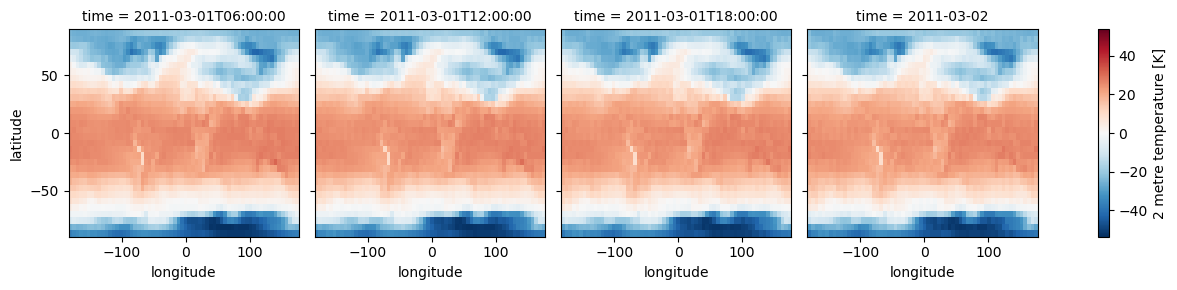

In [60]:
# PLOT MODEL PREDICTIONS
(prediction['2m_temperature'] - 273).plot(x='longitude', y='latitude', col='time', col_wrap=4)

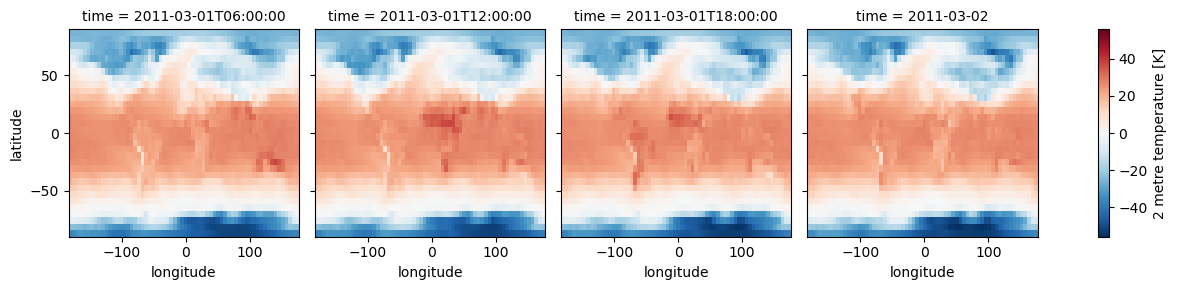

In [61]:
# PLOT ANALYSIS GRIDS (TRUTH)
(analysis_pipeline[COMPARISON_ANALYSIS_TIME]['2m_temperature'] - 273).plot(x='longitude', y='latitude', col='time', col_wrap=4)

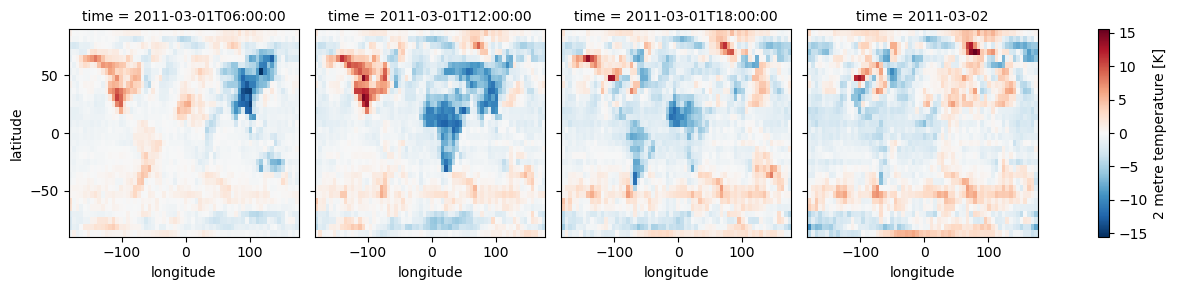

In [62]:
# Plot of Error
(prediction['2m_temperature'] - analysis_pipeline[COMPARISON_ANALYSIS_TIME]['2m_temperature']).plot(x='longitude', y='latitude', col='time', col_wrap=4)

# Things to try next

1. The model needs to train for quite a while to converge. A common problem in machine learning is not knowing quite how long to train a network.
2. The data includes some additional variables. Try training it on more data and chart out how that affects the training effectiveness as measured by the loss function
3. This notebook doesn't include any comparisons to benchmarks such as a persistence model or an alternative model. Charting skill score comparisons would be very useful.
4. A scorecard of results can also be informative, to see accuracy from multiple perspectives
5. Charting the skill of the model with respect to lead time would also be a useful exercise
6. Use PyTorch Lightning logging to graph training loss with respect to training step to understand how the network is converging